# Tutorial 04: Huấn luyện SVM & Random Forest
> Mục tiêu: Hiểu trực quan SVM và RF, áp dụng cho chẩn đoán lỗi ổ lăn CWRU.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_moons
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 100, 'font.size': 12})
print("OK!")


OK!


## 1. SVM trực quan – Ví dụ 2D đơn giản

SVM tìm **đường biên** phân tách các lớp sao cho **khoảng cách an toàn (margin) lớn nhất**.


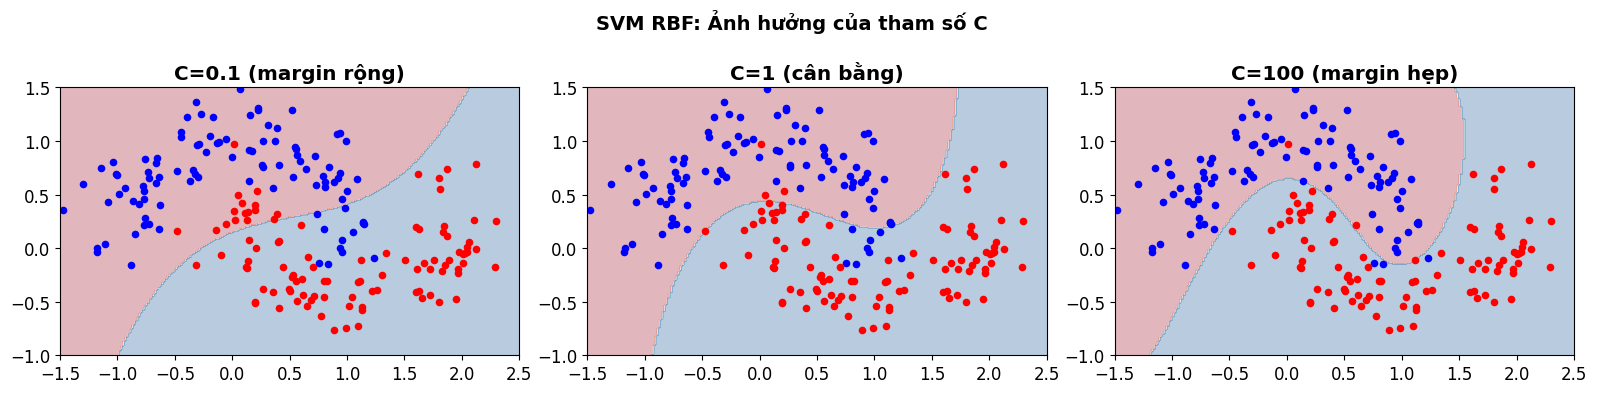

C nhỏ -> đường biên mượt (tổng quát). C lớn -> đường biên uốn theo dữ liệu (dễ overfitting)


In [2]:
# Tạo dữ liệu 2D hình bán nguyệt
X_demo, y_demo = make_moons(n_samples=200, noise=0.2, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (C_val, title) in zip(axes, [(0.1, 'C=0.1 (margin rộng)'), (1, 'C=1 (cân bằng)'), (100, 'C=100 (margin hẹp)')]):
    svm = SVC(kernel='rbf', C=C_val, gamma='auto')
    svm.fit(X_demo, y_demo)
    
    # Vẽ decision boundary
    xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1, 1.5, 200))
    Z = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_demo[y_demo==0,0], X_demo[y_demo==0,1], c='blue', s=20, label='Class 0')
    ax.scatter(X_demo[y_demo==1,0], X_demo[y_demo==1,1], c='red', s=20, label='Class 1')
    ax.set_title(title, fontweight='bold')

plt.suptitle('SVM RBF: Ảnh hưởng của tham số C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("C nhỏ -> đường biên mượt (tổng quát). C lớn -> đường biên uốn theo dữ liệu (dễ overfitting)")


## 2. Random Forest trực quan

Random Forest = nhiều cây quyết định bỏ phiếu. Mỗi cây nhìn góc khác nhau.


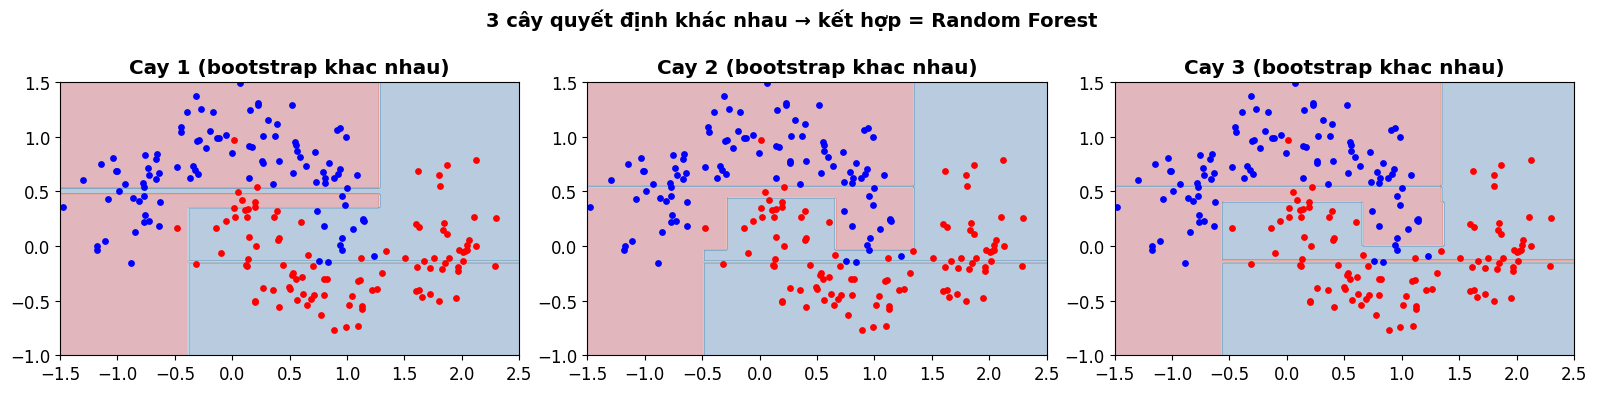

In [3]:
from sklearn.tree import DecisionTreeClassifier

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 3 cây đơn lẻ (mỗi cây khác nhau do bootstrap)
for i, ax in enumerate(axes):
    tree = DecisionTreeClassifier(max_depth=5, random_state=SEED+i)
    # Bootstrap: lấy mẫu ngẫu nhiên
    idx = np.random.choice(len(X_demo), len(X_demo), replace=True)
    tree.fit(X_demo[idx], y_demo[idx])
    
    xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 200), np.linspace(-1, 1.5, 200))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_demo[y_demo==0,0], X_demo[y_demo==0,1], c='blue', s=15)
    ax.scatter(X_demo[y_demo==1,0], X_demo[y_demo==1,1], c='red', s=15)
    ax.set_title(f'Cay {i+1} (bootstrap khac nhau)', fontweight='bold')
plt.suptitle('3 cây quyết định khác nhau → kết hợp = Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Áp dụng cho dữ liệu CWRU

Dùng features đã trích từ Tutorial 03 (hoặc tự trích nếu chạy độc lập).


In [4]:
import os, glob
from scipy.fft import fft, fftfreq
import scipy.stats as sp_stats

SAMPLE_RATE = 12000; WINDOW_SIZE = 2048; OVERLAP = 0.5
DATA_ROOT = "./data"

def segment_signal(signal):
    step = int(WINDOW_SIZE * (1 - OVERLAP))
    n = (len(signal) - WINDOW_SIZE) // step + 1
    return np.array([signal[i*step:i*step+WINDOW_SIZE] for i in range(n)])

def extract_features(seg, fs=SAMPLE_RATE):
    f = {}
    f['mean']=np.mean(seg); f['std']=np.std(seg)
    f['rms']=np.sqrt(np.mean(seg**2)); f['peak']=np.max(np.abs(seg))
    f['p2p']=np.max(seg)-np.min(seg)
    f['skewness']=sp_stats.skew(seg); f['kurtosis']=sp_stats.kurtosis(seg)
    rms=f['rms']; ma=np.mean(np.abs(seg))
    f['crest_factor']=f['peak']/rms if rms>0 else 0
    f['shape_factor']=rms/ma if ma>0 else 0
    f['impulse_factor']=f['peak']/ma if ma>0 else 0
    sm=np.mean(np.sqrt(np.abs(seg)))**2
    f['clearance_factor']=f['peak']/sm if sm>0 else 0
    n=len(seg); yf=np.abs(fft(seg)[:n//2]); freqs=fftfreq(n,1/fs)[:n//2]
    f['fft_energy']=np.sum(yf**2)/n; f['fft_mean']=np.mean(yf)
    f['fft_std']=np.std(yf); f['fft_skewness']=sp_stats.skew(yf)
    f['fft_kurtosis']=sp_stats.kurtosis(yf)
    for lo,hi,nm in [(0,500,'0_500Hz'),(500,2000,'500_2000Hz'),(2000,6000,'2000_6000Hz')]:
        m=(freqs>=lo)&(freqs<hi); f[f'energy_{nm}']=np.sum(yf[m]**2)/n if m.any() else 0
    return f

def parse_label(fn):
    b=fn.replace('_DE.npy','').lower()
    if 'normal' in b: return 'Normal'
    elif b.startswith('ir'): return 'IR'
    elif b.startswith('or'): return 'OR'
    elif b.startswith('b'): return 'B'
    return None

# Kiem tra file CSV da co chua
if os.path.exists("X_features.csv") and os.path.exists("y_labels.csv"):
    X_features = pd.read_csv("X_features.csv")
    y_labels = pd.read_csv("y_labels.csv").iloc[:,0]
    print(f"Doc tu CSV: {X_features.shape}")
else:
    rows, labels = [], []
    for domain in ['0HP','1HP','2HP','3HP']:
        dp = os.path.join(DATA_ROOT, domain)
        if not os.path.isdir(dp): continue
        for fp in sorted(glob.glob(os.path.join(dp, "*.npy"))):
            lb = parse_label(os.path.basename(fp))
            if lb is None: continue
            for s in segment_signal(np.load(fp)):
                rows.append(extract_features(s)); labels.append(lb)
        print(f"{domain}: done")
    X_features = pd.DataFrame(rows)
    y_labels = pd.Series(labels, name='fault_type')
    print(f"Trich dac trung: {X_features.shape}")

print(f"\nPhan bo lop:"); print(y_labels.value_counts())


Doc tu CSV: (22594, 19)

Phan bo lop:
fault_type
OR        10679
B          5458
IR         4805
Normal     1652
Name: count, dtype: int64


## 4. Chia dữ liệu & Huấn luyện


In [5]:
le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
cls_names = list(le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_enc, test_size=0.3, random_state=SEED, stratify=y_enc)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Train: 15815 | Test: 6779


### 4.1. SVM (RBF kernel)


In [6]:
svm_pipe = Pipeline([('scaler', StandardScaler()), 
                     ('svc', SVC(kernel='rbf', probability=True, random_state=SEED))])
grid_svm = GridSearchCV(svm_pipe, 
                        {'svc__C': [1, 10, 100], 'svc__gamma': ['scale', 0.01, 0.1]},
                        cv=3, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train, y_train)
print(f"SVM best: {grid_svm.best_params_}, CV acc: {grid_svm.best_score_:.4f}")

y_pred_svm = grid_svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Test accuracy: {acc_svm:.4f}")


SVM best: {'svc__C': 100, 'svc__gamma': 0.1}, CV acc: 0.9352
Test accuracy: 0.9411


### 4.2. Random Forest


In [7]:
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('rf', RandomForestClassifier(random_state=SEED, n_jobs=-1))])
grid_rf = GridSearchCV(rf_pipe,
                       {'rf__n_estimators': [100, 200], 'rf__max_depth': [10, 20, None]},
                       cv=3, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(f"RF best: {grid_rf.best_params_}, CV acc: {grid_rf.best_score_:.4f}")

y_pred_rf = grid_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Test accuracy: {acc_rf:.4f}")


RF best: {'rf__max_depth': None, 'rf__n_estimators': 200}, CV acc: 0.9719
Test accuracy: 0.9768


## 5. So sánh kết quả


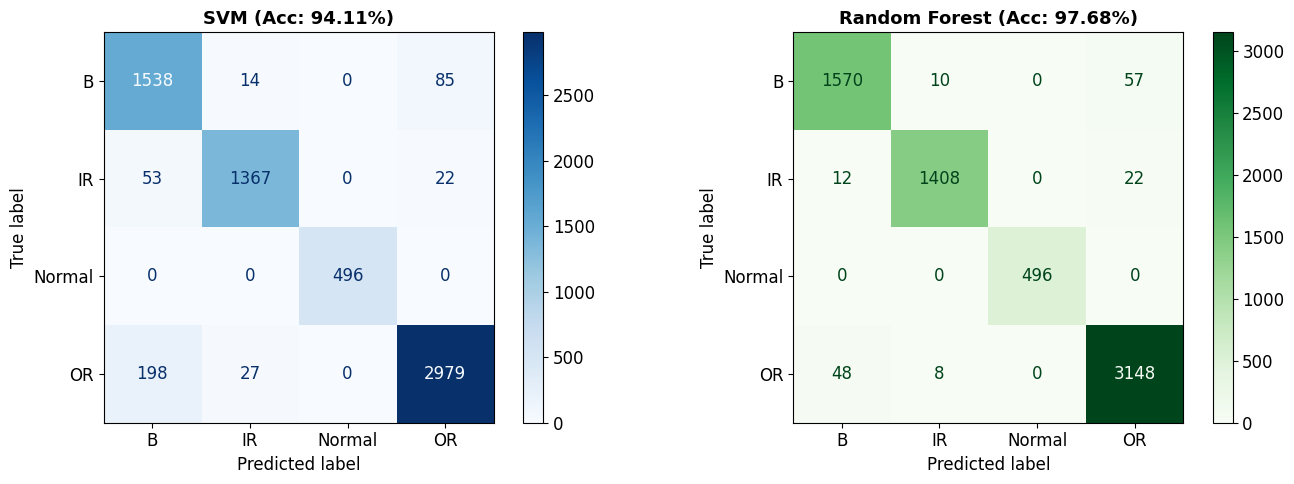


SVM:  94.11%
RF:   97.68%
Winner: Random Forest


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, y_pred, acc, cmap) in zip(axes, [
    ('SVM', y_pred_svm, acc_svm, 'Blues'), ('Random Forest', y_pred_rf, acc_rf, 'Greens')]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=cls_names).plot(ax=ax, cmap=cmap, values_format='d')
    ax.set_title(f'{name} (Acc: {acc:.2%})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nSVM:  {acc_svm:.2%}")
print(f"RF:   {acc_rf:.2%}")
print(f"Winner: {'SVM' if acc_svm>acc_rf else 'Random Forest' if acc_rf>acc_svm else 'Hoa'}")


### Feature Importance (Random Forest)


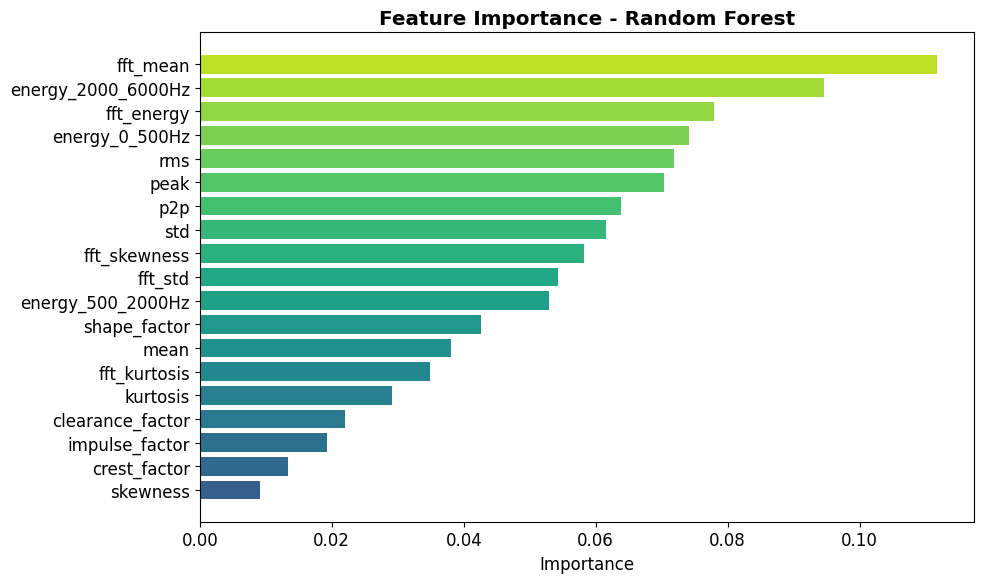

Top 5:
  fft_mean                 : 0.1117
  energy_2000_6000Hz       : 0.0946
  fft_energy               : 0.0780
  energy_0_500Hz           : 0.0741
  rms                      : 0.0719


In [9]:
rf_est = grid_rf.best_estimator_.named_steps['rf']
imp = rf_est.feature_importances_
idx = np.argsort(imp)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(imp)), imp[idx], color=plt.cm.viridis(np.linspace(0.3, 0.9, len(imp))))
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(X_features.columns[idx])
ax.set_xlabel('Importance')
ax.set_title('Feature Importance - Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 5:")
for i in np.argsort(imp)[::-1][:5]:
    print(f"  {X_features.columns[i]:25s}: {imp[i]:.4f}")


## 📝 Bài tập

1. Thử SVM với `kernel='linear'` → accuracy khác bao nhiêu?
2. Tăng `n_estimators` RF lên 500 → accuracy cải thiện không?
3. Thử XGBoost: `from xgboost import XGBClassifier`
4. Chỉ dùng Top 5 features → accuracy thay đổi bao nhiêu?

---
*Tutorial 04/05 – Khóa đào tạo "Ứng dụng ML trong chẩn đoán thiết bị quay"*
